# Résolution de l'équation de Schrödinger 

Dans ce TP, on va chercher à résoudre l'équation de Schrödinger indépendante du temps dans un système d'unité où la constante de Planck réduite et la masse sont unitaires. L'unité d'énergie devient alors le Hartree et l'unité de longueux le Bohr.
L'équation de Schrödinger indépendante du temps s'écrit alors $$-\frac{1}{2}\frac{d^{2}\phi(x)}{dx^{2}} + V(x)\phi(x) = E \phi(x)$$

## La méthode des éléments finis

## 1

Il faut que $\delta$ << longueurs typiques de variation de $\phi(x)$, et que L>> taille typique du domaine de présence de l'électron.

## 2

Au point $x_{i}$, la dérivée seconde s'approxime par $$\frac{d^{2}\phi_{i}}{dx^{2}}= \frac{\phi_{i+1}+\phi_{i-1}-2\phi_{i}}{\delta^{2}}$$

On en déduit l'équation de Schrödinger sous forme discrétisée $$-\frac{1}{2}\frac{\phi_{i+1}+\phi_{i-1}-2\phi_{i}}{\delta^{2}} + V_{i}\phi_{i} = E \phi_{i}$$

## 3

On peut écrire la matrice H comme une matrice tri-diagonale. Cela impose que la fonction d'onde soit nulle en dehors de L. La probabilité que l'électron existe en dehors de l'intervalle L est nulle.

## 4

On doit maintenant résoudre un problème aux valeurs propres.

## Mise en œuvre numérique

In [301]:
"""Importation des modules"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import *
import scipy.special
from time import *

## 5

In [302]:
n=100
L=5
X=np.linspace(-L/2,L/2,n) #vecteur abcisse 

## 6

In [303]:
def PuitsCarre(n): #en prenant un puit carré de largeur L centré en 0
    return np.zeros(n)

m=1
hbar=1
w=1

def PuitsHarmonique(X): 
    return 0.5*X**2

def Schrodinger(V,X): 
    d=X[1]-X[0]  #pas d'échantillonnage
    Hd=np.zeros(n) #diagonale de la matrice H
    for k in range(n):
        Hd[k]=1/(d**2) + V[k]
    Hsousd=np.zeros(n-1) #sous-diagonale de la matrice H
    for k in range(n-1):
        Hsousd[k]=-1/(2*(d**2))
    valeurs_propres, vecteurs_propres = eigh_tridiagonal(Hd,Hsousd)
    return valeurs_propres, vecteurs_propres


## Etude théorique et numérique

## Puits carré infini

## 7

Dans le cas du puits carré infini, les niveaux d'énergie sont d'expressions $$E_{p}=\frac{1}{2}(\frac{p\pi}{L})^{2},  p\in Z$$

Pour p impaire, $\phi(x)=\sqrt{\frac{2}{L}}cos (\frac{p\pi}{L}x)$

Pour p paire, $\phi(x)=\sqrt{\frac{2}{L}}sin (\frac{p\pi}{L}x)$

## 8

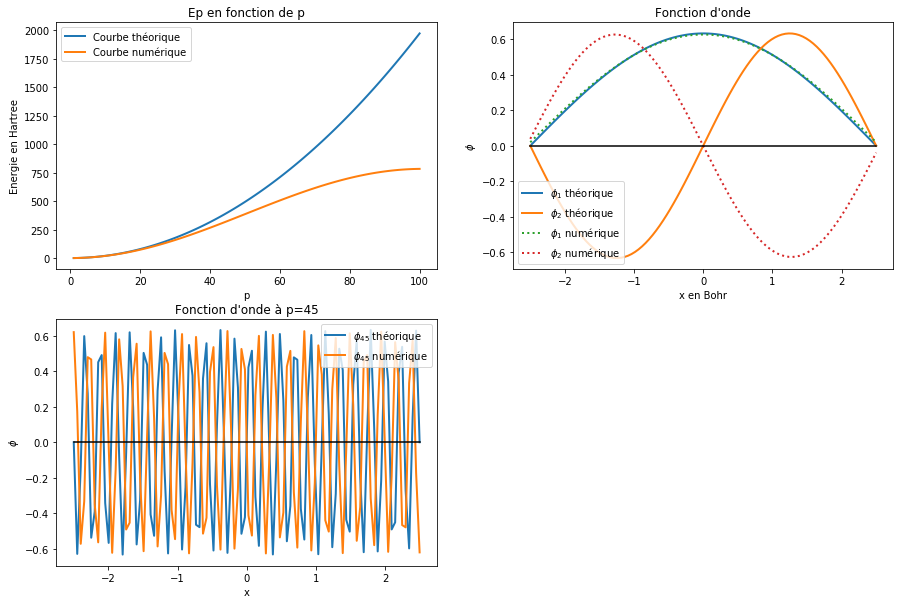

In [304]:
pmax=n # n valeurs propres sont calculées par eigh_tridiagonal, p varie donc entre 1 et pmax = n

P=np.arange(1, pmax+1) #les énergies commencent à p=1

Ep=(1/2)*(P*np.pi/L)**2 #liste des énergies propres calculées analytiquement 

Fct_onde=np.zeros((n,n)) #matrice des vecteurs propres calculés analytiquement
for k in P:
    if k%2==1:
        Fct_onde[:,k-1]=(2/L)**0.5*np.cos(k*np.pi/L*X) #distinction selon que p soit paire ou impaire
    else:
        Fct_onde[:,k-1]=(2/L)**0.5*np.sin(k*np.pi/L*X)


phi=Schrodinger(PuitsCarre(n), X)[1]

d=X[1]-X[0]
for k in range(n):
    phi[:,k]=phi[:,k]/(d**0.5) # normalisation des fonctions d'ondes


plt.figure(figsize=(15,10))

plt.subplot(2,2,1)    
plt.plot(P,Ep, linewidth=2, label="Courbe théorique")
plt.plot(P, Schrodinger(PuitsCarre(n), X)[0],linewidth=2, label="Courbe numérique")
plt.title("Ep en fonction de p")
plt.xlabel('p')
plt.ylabel('Energie en Hartree')
plt.legend()


plt.subplot(2,2,2)
plt.plot(X, Fct_onde[:,0],linewidth=2, label="$\phi_{1}$ théorique") #je représente les 2 premières fonctions d'onde
plt.plot(X, Fct_onde[:,1],linewidth=2, label="$\phi_{2}$ théorique") 
plt.plot(X, phi[:,0], linestyle=':',linewidth=2, label="$\phi_{1}$ numérique")
plt.plot(X, phi[:,1], linestyle=':',linewidth=2, label="$\phi_{2}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde")
plt.xlabel('x en Bohr')
plt.ylabel('$\phi$')
plt.legend()

plt.subplot(2,2,3)
plt.plot(X,Fct_onde[:,45],linewidth=2, label="$\phi_{45}$ théorique")
plt.plot(X, phi[:,45], linewidth=2, label="$\phi_{45}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde à p=45")
plt.xlabel('x')
plt.ylabel('$\phi$')
plt.legend()

plt.show()


On observe qu'à partir de la 30ème énergie propre, les courbes théoriques et numériques se séparent. 
Les fonctions d'ondes numériques et théoriques pour p=45 ne se superposent plus, car l'échantillonnage est trop grossier.
Si on lance le programme pour n=200, les énergies et fonctions d'ondes coincident bien plus.

## 9

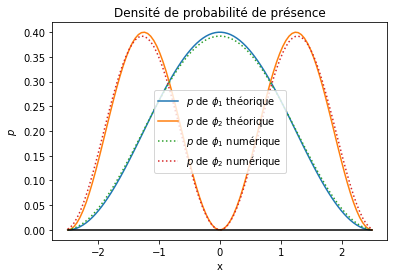

In [305]:
plt.plot(X, np.abs(Fct_onde[:,0])**2, label="$p$ de $\phi_{1}$ théorique") 
plt.plot(X, np.abs(Fct_onde[:,1])**2, label="$p$ de $\phi_{2}$ théorique")  
plt.plot(X, np.abs(phi[:,0])**2, linestyle=':', label="$p$ de $\phi_{1}$ numérique")
plt.plot(X, np.abs(phi[:,1])**2, linestyle=':', label="$p$ de $\phi_{2}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Densité de probabilité de présence")
plt.xlabel('x')
plt.ylabel('$p$')
plt.legend()


plt.show()


## Potentiel harmonique

## 10

Dans le cas du potentiel harmonique, les niveaux d'énergies sont d'expressions $$E_{p}=(p+\frac{1}{2})$$
L'énergie de l'état fondamental est donc $\frac{1}{2}$, atteinte en $p=0$ cette fois.

## 11

n=100 pour L=5


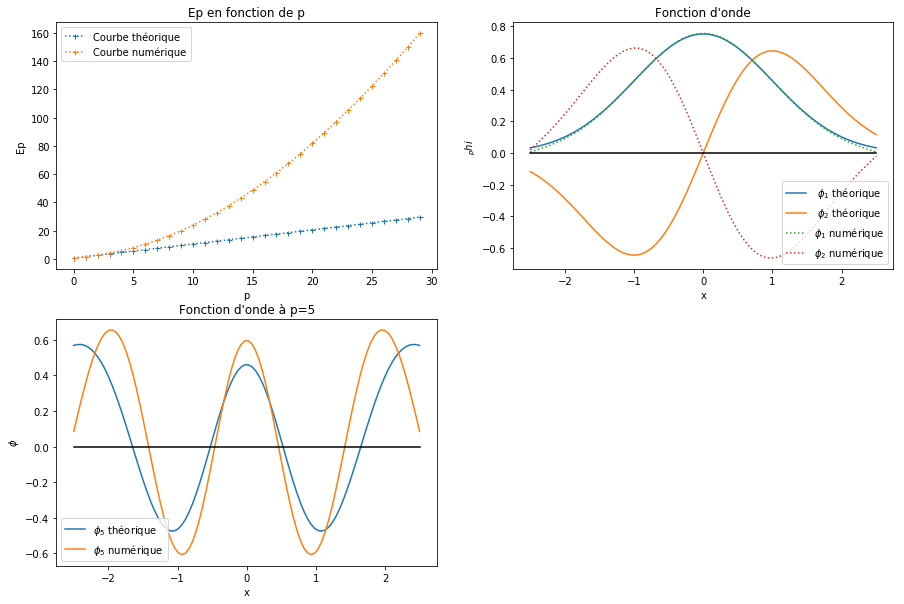

In [306]:
k=1
w=1


pmax=30 # on prend cette fois pmax= 30 et non 1000, car à partir de k=31, le terme (np.pi**0.5)*(2**k)*(np.math.factorial(k))
        #  dans l'expression de la fonction d'onde n'est plus calculé par l'ordinateur qui indique la valeur 0
        # (dépassement de capacités)
        
P=np.arange(pmax) #L'énergie fondamental est définie pour p=0 cette fois et non p=1
Ep_harmo=(P+0.5) # Vecteur des Ep théoriques pour le potentiel harmonique


Fct_onde_harmo=np.zeros((n,pmax)) #matrice des pmax premières fonctions d'ondes
for k in P:
    Fct_onde_harmo[:,k]=((np.pi**0.5)*(2**k)*(np.math.factorial(k)))**(-0.5)*scipy.special.eval_hermite(k,X)*np.exp(-(X**2)/2)

phiharmo=Schrodinger(PuitsHarmonique(X),X)[1]

for k in range(pmax):
    phiharmo[:,k]=phiharmo[:,k]/(d**0.5)


print("n=100 pour L=5")

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)    
plt.plot(P, Ep_harmo, marker='+',markersize=5, linestyle=':', label="Courbe théorique")
plt.plot(P, Schrodinger(PuitsHarmonique(X),X)[0][:30], marker='+',markersize=5, linestyle=':', label="Courbe numérique")
plt.title("Ep en fonction de p")
plt.xlabel('p')
plt.ylabel('Ep')
plt.legend()


plt.subplot(2,2,2)
plt.plot(X,Fct_onde_harmo[:,0], label=" $\phi_{1}$ théorique")
plt.plot(X,Fct_onde_harmo[:,1], label=" $\phi_{2}$ théorique")
plt.plot(X,phiharmo[:,0], linestyle=':', label="$\phi_{1}$ numérique")
plt.plot(X,phiharmo[:,1], linestyle=':', label="$\phi_{2}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde")
plt.xlabel('x')
plt.ylabel('$_phi$')
plt.legend()

plt.subplot(2,2,3)
plt.plot(X,Fct_onde_harmo[:,4], label="$\phi_{5}$ théorique")
plt.plot(X, phiharmo[:,4], label="$\phi_{5}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde à p=5")
plt.xlabel('x')
plt.ylabel('$\phi$')
plt.legend()


plt.show()


Lors de la représentation des 2 premières fonctions d'ondes, on observe qu'elles sont non nulles aux bords.
On doit donc définir un intervalle L plus grand (cf question 12).

On observe également que les énergies propres théoriques et numériques diffèrent dès $p=5$. Les fonctions d'ondes ne coïncident plus vraiment. 
On doit donc prendre une résolution n plus importante afin que les courbes des énergies et des fonctions d'ondes numériques et théoriques coïncident davantage (cf question 13).

## 12

n=100 pour L=20


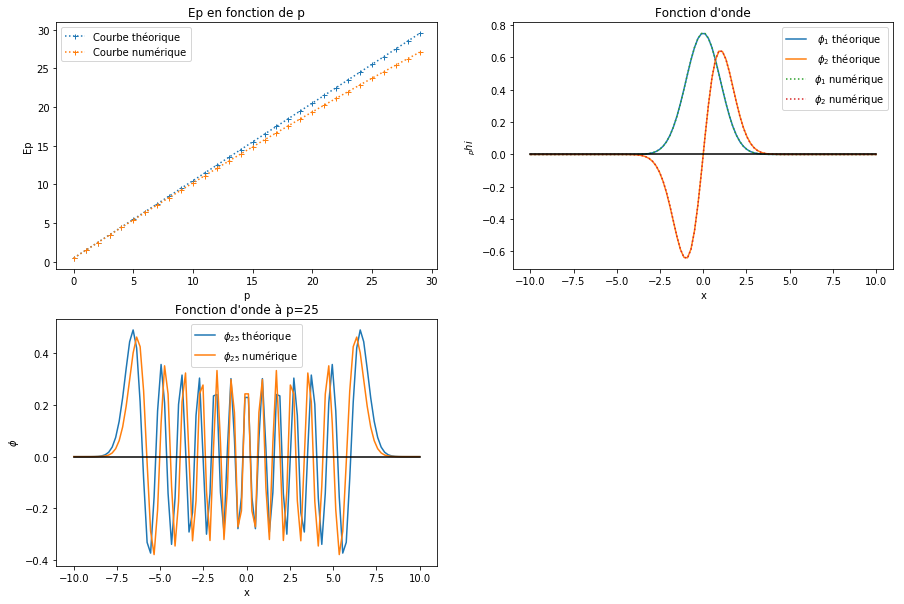

In [307]:
"""Reprise de la question précédente avec n=100 et L=20"""

n=100
L=20
X=np.linspace(-L/2,L/2,n) #vecteur abcisse
d=X[1]-X[0]

pmax=30 # on prend cette fois pmax= 30 et non 1000, car à partir de k=31, le terme (np.pi**0.5)*(2**k)*(np.math.factorial(k))
        #  dans l'expression de la fonction d'onde n'est plus calculé par l'ordinateur qui indique la valeur 0
        # (dépassement de capacités)
        
P=np.arange(pmax) #L'énergie fondamental est définie pour p=0 cette fois et non p=1
Ep_harmo=(P+0.5) # Vecteur des Ep théoriques pour le potentiel harmonique


Fct_onde_harmo=np.zeros((n,pmax)) #matrice des pmax premières fonctions d'ondes
for k in P:
    Fct_onde_harmo[:,k]=((np.pi**0.5)*(2**k)*(np.math.factorial(k)))**(-0.5)*scipy.special.eval_hermite(k,X)*np.exp(-(X**2)/2)

phiharmo=Schrodinger(PuitsHarmonique(X),X)[1]

for k in range(pmax):
    phiharmo[:,k]=phiharmo[:,k]/(d**0.5)


print("n=100 pour L=20")

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)    
plt.plot(P, Ep_harmo, marker='+',markersize=5, linestyle=':', label="Courbe théorique")
plt.plot(P, Schrodinger(PuitsHarmonique(X),X)[0][:30], marker='+',markersize=5, linestyle=':', label="Courbe numérique")
plt.title("Ep en fonction de p")
plt.xlabel('p')
plt.ylabel('Ep')
plt.legend()


plt.subplot(2,2,2)
plt.plot(X,Fct_onde_harmo[:,0], label=" $\phi_{1}$ théorique")
plt.plot(X,Fct_onde_harmo[:,1], label=" $\phi_{2}$ théorique")
plt.plot(X,phiharmo[:,0], linestyle=':', label="$\phi_{1}$ numérique")
plt.plot(X,phiharmo[:,1], linestyle=':', label="$\phi_{2}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde")
plt.xlabel('x')
plt.ylabel('$_phi$')
plt.legend()

plt.subplot(2,2,3)
plt.plot(X,Fct_onde_harmo[:,24], label="$\phi_{25}$ théorique")
plt.plot(X, phiharmo[:,24], label="$\phi_{25}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde à p=25")
plt.xlabel('x')
plt.ylabel('$\phi$')
plt.legend()


plt.show()


On observe qu'avec L=20, les fonctions d'onde sont bien nulles en dehors de l'intervalle.

## 13

n=200 pour L=20


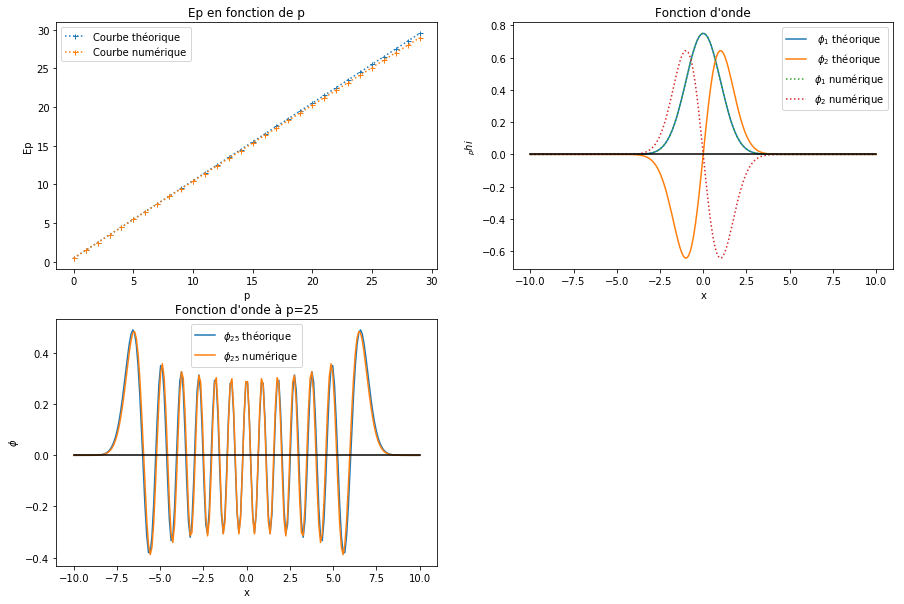

In [308]:
"""Reprise de la question précédente avec n=200 et L=20"""

n=200
L=20
X=np.linspace(-L/2,L/2,n) #vecteur abcisse
d=X[1]-X[0]

pmax=30 # on prend cette fois pmax= 30 et non 1000, car à partir de k=31, le terme (np.pi**0.5)*(2**k)*(np.math.factorial(k))
        #  dans l'expression de la fonction d'onde n'est plus calculé par l'ordinateur qui indique la valeur 0
        # (dépassement de capacités)
        
P=np.arange(pmax) #L'énergie fondamental est définie pour p=0 cette fois et non p=1
Ep_harmo=(P+0.5) # Vecteur des Ep théoriques pour le potentiel harmonique


Fct_onde_harmo=np.zeros((n,pmax)) #matrice des pmax premières fonctions d'ondes
for k in P:
    Fct_onde_harmo[:,k]=((np.pi**0.5)*(2**k)*(np.math.factorial(k)))**(-0.5)*scipy.special.eval_hermite(k,X)*np.exp(-(X**2)/2)

phiharmo=Schrodinger(PuitsHarmonique(X),X)[1]

for k in range(pmax):
    phiharmo[:,k]=phiharmo[:,k]/(d**0.5)


print("n=200 pour L=20")

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)    
plt.plot(P, Ep_harmo, marker='+',markersize=5, linestyle=':', label="Courbe théorique")
plt.plot(P, Schrodinger(PuitsHarmonique(X),X)[0][:30], marker='+',markersize=5, linestyle=':', label="Courbe numérique")
plt.title("Ep en fonction de p")
plt.xlabel('p')
plt.ylabel('Ep')
plt.legend()


plt.subplot(2,2,2)
plt.plot(X,Fct_onde_harmo[:,0], label=" $\phi_{1}$ théorique")
plt.plot(X,Fct_onde_harmo[:,1], label=" $\phi_{2}$ théorique")
plt.plot(X,phiharmo[:,0], linestyle=':', label="$\phi_{1}$ numérique")
plt.plot(X,phiharmo[:,1], linestyle=':', label="$\phi_{2}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde")
plt.xlabel('x')
plt.ylabel('$_phi$')
plt.legend()

plt.subplot(2,2,3)
plt.plot(X,Fct_onde_harmo[:,24], label="$\phi_{25}$ théorique")
plt.plot(X, phiharmo[:,24], label="$\phi_{25}$ numérique")
plt.plot(X,np.zeros(n),color='k')
plt.title("Fonction d'onde à p=25")
plt.xlabel('x')
plt.ylabel('$\phi$')
plt.legend()


plt.show()


On observe que pour n=200, les courbes théoriques et numériques des énergies et des fonctions d'ondes coïncident beaucoup plus que pour n=100. La résolution a bien été améliorée.

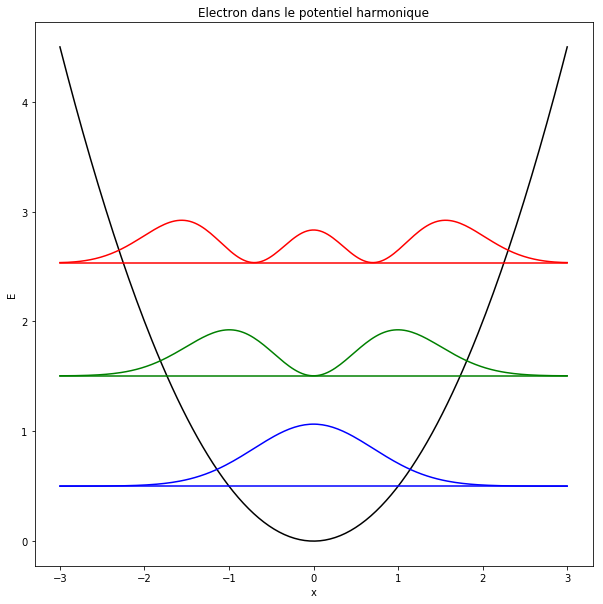

In [309]:
"""n=200 et L=6"""
n=200
L=6
X=np.linspace(-L/2,L/2,n) #vecteur abcisse
d=X[1]-X[0]

pmax=30 
P=np.arange(pmax) 
Ep_harmo=(P+0.5) 

Fct_onde_harmo=np.zeros((n,pmax)) 
for k in P:
    Fct_onde_harmo[:,k]=((np.pi**0.5)*(2**k)*(np.math.factorial(k)))**(-0.5)*scipy.special.eval_hermite(k,X)*np.exp(-(X**2)/2)

phiharmo=Schrodinger(PuitsHarmonique(X),X)[1]

for k in range(pmax):
    phiharmo[:,k]=phiharmo[:,k]/(d**0.5)

"""Tracé du graphique"""

plt.figure(figsize=(10,10))
plt.plot(X, PuitsHarmonique(X), color='k')
plt.plot(X, Schrodinger(PuitsHarmonique(X),X)[0][0]*np.ones(n), color='b')
plt.plot(X, Schrodinger(PuitsHarmonique(X),X)[0][1]*np.ones(n), color= 'g')
plt.plot(X, Schrodinger(PuitsHarmonique(X),X)[0][2]*np.ones(n), color='r')

plt.plot(X, (phiharmo[:,0])**2 + Schrodinger(PuitsHarmonique(X),X)[0][0], color='b')
plt.plot(X, (phiharmo[:,1])**2 + Schrodinger(PuitsHarmonique(X),X)[0][1], color='g')
plt.plot(X, (phiharmo[:,2])**2 + Schrodinger(PuitsHarmonique(X),X)[0][2], color='r')


plt.title("Electron dans le potentiel harmonique")
plt.xlabel('x')
plt.ylabel('E')

plt.show()

## Double puits

## 14

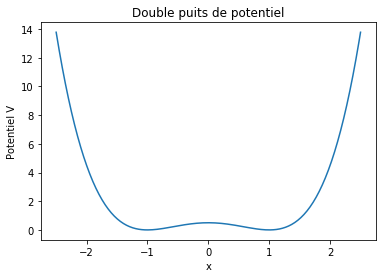

In [310]:
n=200
L=5
X=np.linspace(-L/2,L/2,n) #vecteur abcisse
d=X[1]-X[0]


def Double_puits(X,V0):
    return V0*(X**2-1)**2

plt.plot(X,Double_puits(X,0.5))
plt.title("Double puits de potentiel")
plt.xlabel('x')
plt.ylabel('Potentiel V')
plt.show()

## 15

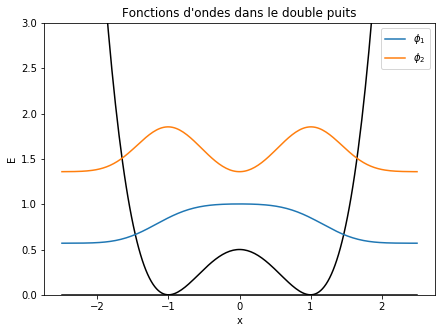

In [311]:
phi1=Schrodinger(Double_puits(X,0.5), X)[1][:,0]/(d**0.5)
phi2=Schrodinger(Double_puits(X,0.5), X)[1][:,1]/(d**0.5)

E1=Schrodinger(Double_puits(X,0.5), X)[0][0]
E2=Schrodinger(Double_puits(X,0.5), X)[0][1]
    
"""Tracé du graphique"""

plt.figure(figsize=(7,5))
plt.plot(X, Double_puits(X,0.5), color='k')
plt.plot(X, np.zeros(n),color='k')

plt.plot(X, phi1**2 + E1, label="$\phi_{1}$")
plt.plot(X, phi2**2 + E2, label="$\phi_{2}$")


plt.title("Fonctions d'ondes dans le double puits")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(0,3)
plt.legend()

plt.show()



Dès l'état fondamental, l'électron a suffisamment d'énergie pour passer la barrière de potentiel qui sépare les puits. Le double puits n'est pas visible à l'échelle des 2 premières fonctions d'onde.

## 16

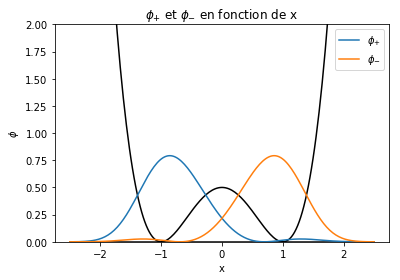

In [312]:
phiplus=(phi1+phi2)/(2**0.5)
phimoins=(phi1-phi2)/(2**0.5)

plt.plot(X, Double_puits(X,0.5), color='k')
plt.plot(X, np.zeros(n),color='k')

plt.plot(X, phiplus**2, label="$\phi_{+}$")
plt.plot(X, phimoins**2, label="$\phi_{-}$")

plt.title("$\phi_{+}$ et $\phi_{-}$ en fonction de x")
plt.xlabel('x')
plt.ylabel('$\phi$')
plt.ylim(0,2)
plt.legend()

plt.show()

$\phi_{+}$ est presque sûrement dans le puit de droite, et $\phi_{-}$ est presque sûrement dans celui de gauche.

## 17

$$\phi_{+}(x,t) = \frac{1}{\sqrt{2}} e^{-i\frac{E_{1}}{h}t}(\phi_{1}(x)+\phi_{2}(x) e^{-i\frac{(E_{2}-E_{2})}{h}t})$$

On observe une pulsation d'effet tunnel, dont on déduit l'expression de la fréquence d'effet tunnel dans notre système d'unité:
$$f=\frac{E_{2}-E_{1}}{2\pi}$$

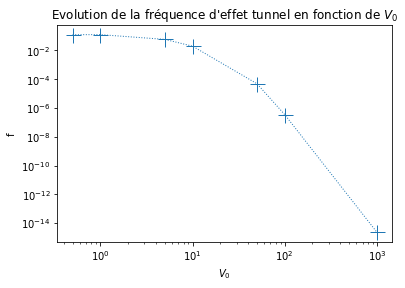

In [313]:
L=np.array([0.5,1,5,10,50,100,1000]) #liste des potentiels V0
F=np.zeros(len(L)) 
for k in range(len(L)):
    E1=Schrodinger(Double_puits(X, L[k]), X)[0][0]
    E2=Schrodinger(Double_puits(X, L[k]), X)[0][1]
    F[k]=(E2-E1)/(2*np.pi) #liste des fréquences d'effet tunnel

plt.loglog(L,F,marker='+',markersize=15, linestyle=':',linewidth=1)
plt.title("Evolution de la fréquence d'effet tunnel en fonction de $V_{0}$")
plt.xlabel('$V_{0}$')
plt.ylabel('f')
plt.show()

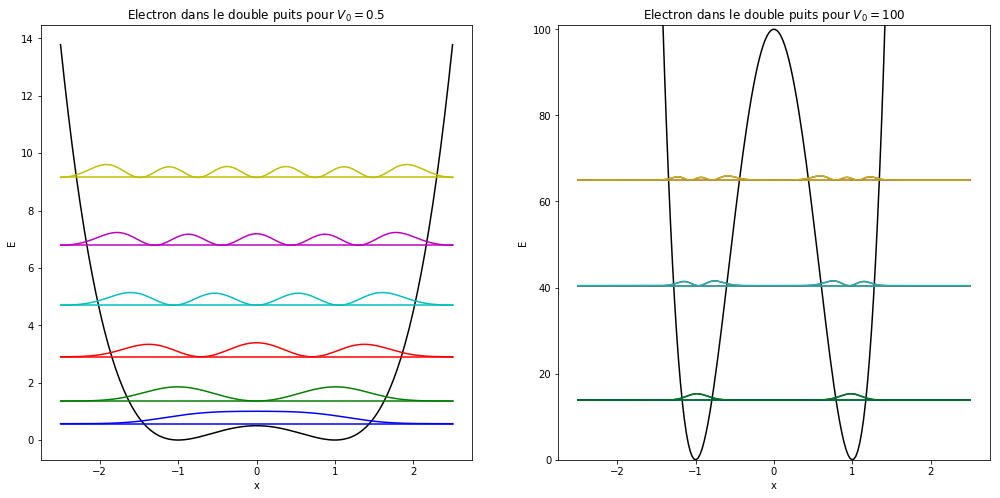

In [314]:

plt.figure(figsize=(17,8))

"""Cas V0=0.5"""

phidoublepuitsbas=Schrodinger(Double_puits(X, 0.5),X)[1]/(d**0.5)

plt.subplot(1,2,1) 
plt.plot(X ,Double_puits(X, 0.5), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 0.5),X)[0][0]*np.ones(n), color='b')
plt.plot(X, Schrodinger(Double_puits(X, 0.5),X)[0][1]*np.ones(n), color='g')
plt.plot(X, Schrodinger(Double_puits(X, 0.5),X)[0][2]*np.ones(n), color='r')
plt.plot(X, Schrodinger(Double_puits(X, 0.5),X)[0][3]*np.ones(n), color='c')
plt.plot(X, Schrodinger(Double_puits(X, 0.5),X)[0][4]*np.ones(n), color='m')
plt.plot(X, Schrodinger(Double_puits(X, 0.5),X)[0][5]*np.ones(n), color='y')

plt.plot(X, (phidoublepuitsbas[:,0])**2 + Schrodinger(Double_puits(X, 0.5),X)[0][0], color='b')
plt.plot(X, (phidoublepuitsbas[:,1])**2 + Schrodinger(Double_puits(X, 0.5),X)[0][1], color='g')
plt.plot(X, (phidoublepuitsbas[:,2])**2 + Schrodinger(Double_puits(X, 0.5),X)[0][2], color='r')
plt.plot(X, (phidoublepuitsbas[:,3])**2 + Schrodinger(Double_puits(X, 0.5),X)[0][3], color='c')
plt.plot(X, (phidoublepuitsbas[:,4])**2 + Schrodinger(Double_puits(X, 0.5),X)[0][4], color='m')
plt.plot(X, (phidoublepuitsbas[:,5])**2 + Schrodinger(Double_puits(X, 0.5),X)[0][5], color='y')

plt.title("Electron dans le double puits pour $V_{0}=0.5$")
plt.xlabel('x')
plt.ylabel('E')



"""Cas V0=100"""

phidoublepuitshaut=Schrodinger(Double_puits(X, 100),X)[1]/(d**0.5)

plt.subplot(1,2,2) 
plt.plot(X ,Double_puits(X, 100), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][0]*np.ones(n), color='b')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][1]*np.ones(n), color='g')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][2]*np.ones(n), color='r')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][3]*np.ones(n), color='c')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][4]*np.ones(n), color='m')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][5]*np.ones(n), color='y')

plt.plot(X, (phidoublepuitshaut[:,0])**2 + Schrodinger(Double_puits(X, 100),X)[0][0], color='b')
plt.plot(X, (phidoublepuitshaut[:,1])**2 + Schrodinger(Double_puits(X, 100),X)[0][1], color='g')
plt.plot(X, (phidoublepuitshaut[:,2])**2 + Schrodinger(Double_puits(X, 100),X)[0][2], color='r')
plt.plot(X, (phidoublepuitshaut[:,3])**2 + Schrodinger(Double_puits(X, 100),X)[0][3], color='c')
plt.plot(X, (phidoublepuitshaut[:,4])**2 + Schrodinger(Double_puits(X, 100),X)[0][4], color='m')
plt.plot(X, (phidoublepuitshaut[:,5])**2 + Schrodinger(Double_puits(X, 100),X)[0][5], color='y')

plt.title("Electron dans le double puits pour $V_{0}=100$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(0,101)

plt.show()


Si on réalise un zoom sur les niveaux d'énergie de la figure 2 où $V_{0}=100$ :

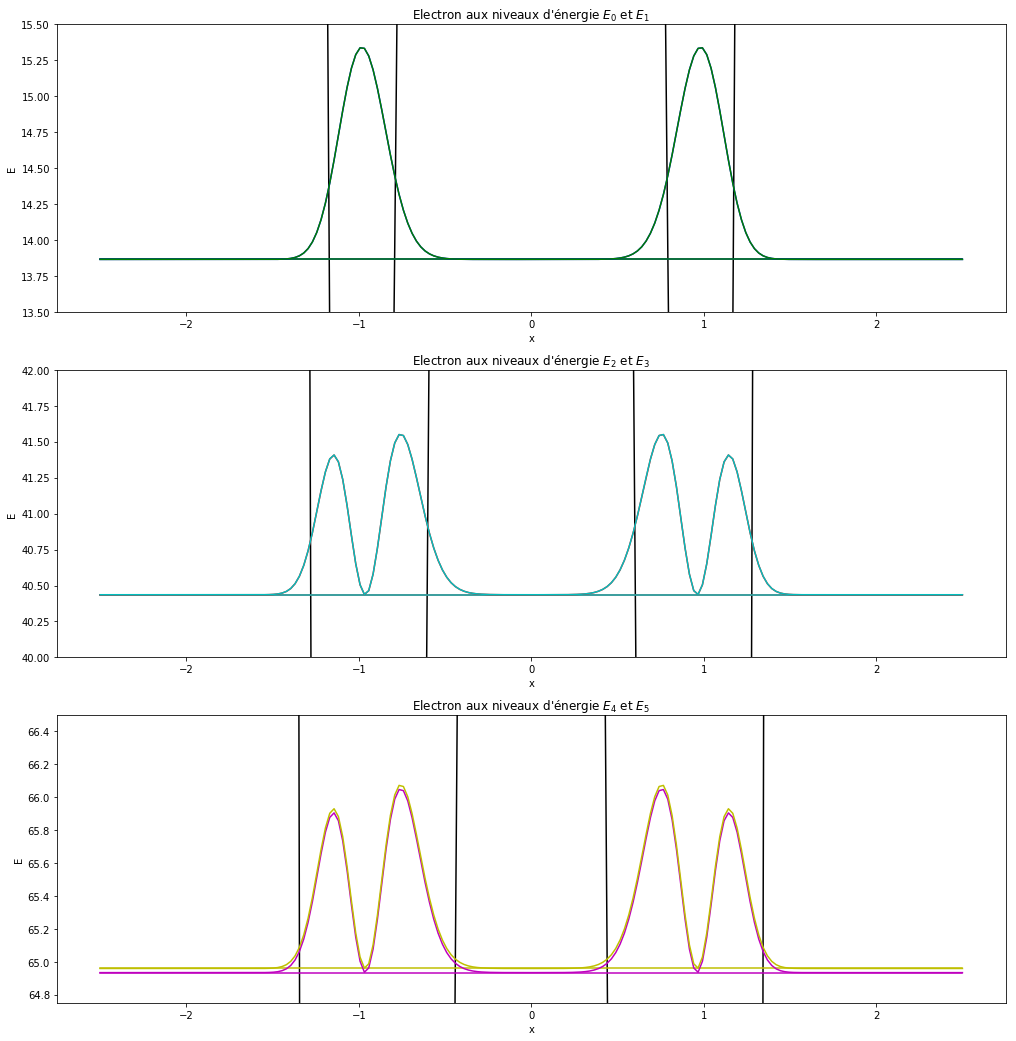

In [315]:
"""Cas V0=100"""
phidoublepuitshaut=Schrodinger(Double_puits(X, 100),X)[1]/(d**0.5)
plt.figure(figsize=(17,18))


"""Electron aux niveaux d'énergie E0 et E1"""

plt.subplot(3,1,1)
plt.plot(X ,Double_puits(X, 100), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][0]*np.ones(n), color='b')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][1]*np.ones(n), color='g')
plt.plot(X, (phidoublepuitshaut[:,0])**2 + Schrodinger(Double_puits(X, 100),X)[0][0], color='b')
plt.plot(X, (phidoublepuitshaut[:,1])**2 + Schrodinger(Double_puits(X, 100),X)[0][1], color='g')
plt.title("Electron aux niveaux d'énergie $E_{0}$ et $E_{1}$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(13.5,15.5)


"""Electron aux niveaux d'énergie E2 et E3"""

plt.subplot(3,1,2) 
plt.plot(X ,Double_puits(X, 100), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][2]*np.ones(n), color='r')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][3]*np.ones(n), color='c')
plt.plot(X, (phidoublepuitshaut[:,2])**2 + Schrodinger(Double_puits(X, 100),X)[0][2], color='r')
plt.plot(X, (phidoublepuitshaut[:,3])**2 + Schrodinger(Double_puits(X, 100),X)[0][3], color='c')
plt.title("Electron aux niveaux d'énergie $E_{2}$ et $E_{3}$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(40,42)


"""Electron aux niveaux d'énergie E4 et E5"""

plt.subplot(3,1,3) 
plt.plot(X ,Double_puits(X, 100), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][4]*np.ones(n), color='m')
plt.plot(X, Schrodinger(Double_puits(X, 100),X)[0][5]*np.ones(n), color='y')
plt.plot(X, (phidoublepuitshaut[:,2])**2 + Schrodinger(Double_puits(X, 100),X)[0][4], color='m')
plt.plot(X, (phidoublepuitshaut[:,3])**2 + Schrodinger(Double_puits(X, 100),X)[0][5], color='y')
plt.title("Electron aux niveaux d'énergie $E_{4}$ et $E_{5}$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(64.75,66.5)

plt.show()


On observe que les niveaux d'énergie se confondent deux à deux. En particulier, l'état fondamental (niveau $E_{0}$) et le premier état excité (niveau $E_{10}$) sont indiscernables à l'écran. Cela signifie que l'électron est très facilement excitable.
De plus, on observe que l'électron a une probabilité de présence non nulle sous la barrière de potentiel que représente la séparation des 2 puits.

## 18

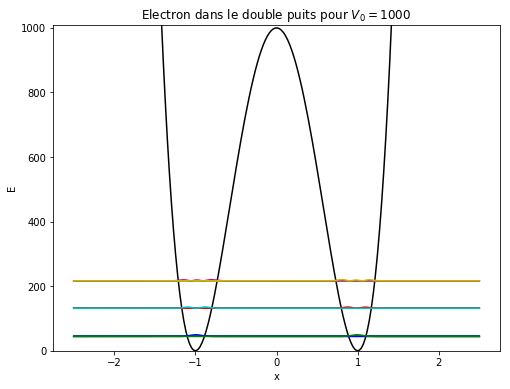

In [316]:
"""Cas V0=1000"""

phidoublepuitshaut=Schrodinger(Double_puits(X, 1000),X)[1]/(d**0.5)

plt.figure(figsize=(8,6)) 

plt.plot(X ,Double_puits(X, 1000), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][0]*np.ones(n), color='b')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][1]*np.ones(n), color='g')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][2]*np.ones(n), color='r')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][3]*np.ones(n), color='c')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][4]*np.ones(n), color='m')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][5]*np.ones(n), color='y')

plt.plot(X, (phidoublepuitshaut[:,0])**2 + Schrodinger(Double_puits(X, 1000),X)[0][0], color='b')
plt.plot(X, (phidoublepuitshaut[:,1])**2 + Schrodinger(Double_puits(X, 1000),X)[0][1], color='g')
plt.plot(X, (phidoublepuitshaut[:,2])**2 + Schrodinger(Double_puits(X, 1000),X)[0][2], color='r')
plt.plot(X, (phidoublepuitshaut[:,3])**2 + Schrodinger(Double_puits(X, 1000),X)[0][3], color='c')
plt.plot(X, (phidoublepuitshaut[:,4])**2 + Schrodinger(Double_puits(X, 1000),X)[0][4], color='m')
plt.plot(X, (phidoublepuitshaut[:,5])**2 + Schrodinger(Double_puits(X, 1000),X)[0][5], color='y')
plt.title("Electron dans le double puits pour $V_{0}=1000$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(0,1010)

plt.show()


Si on réalise un zoom sur les niveaux d'énergie de la figure 2 où $V_{0}=1000$ :

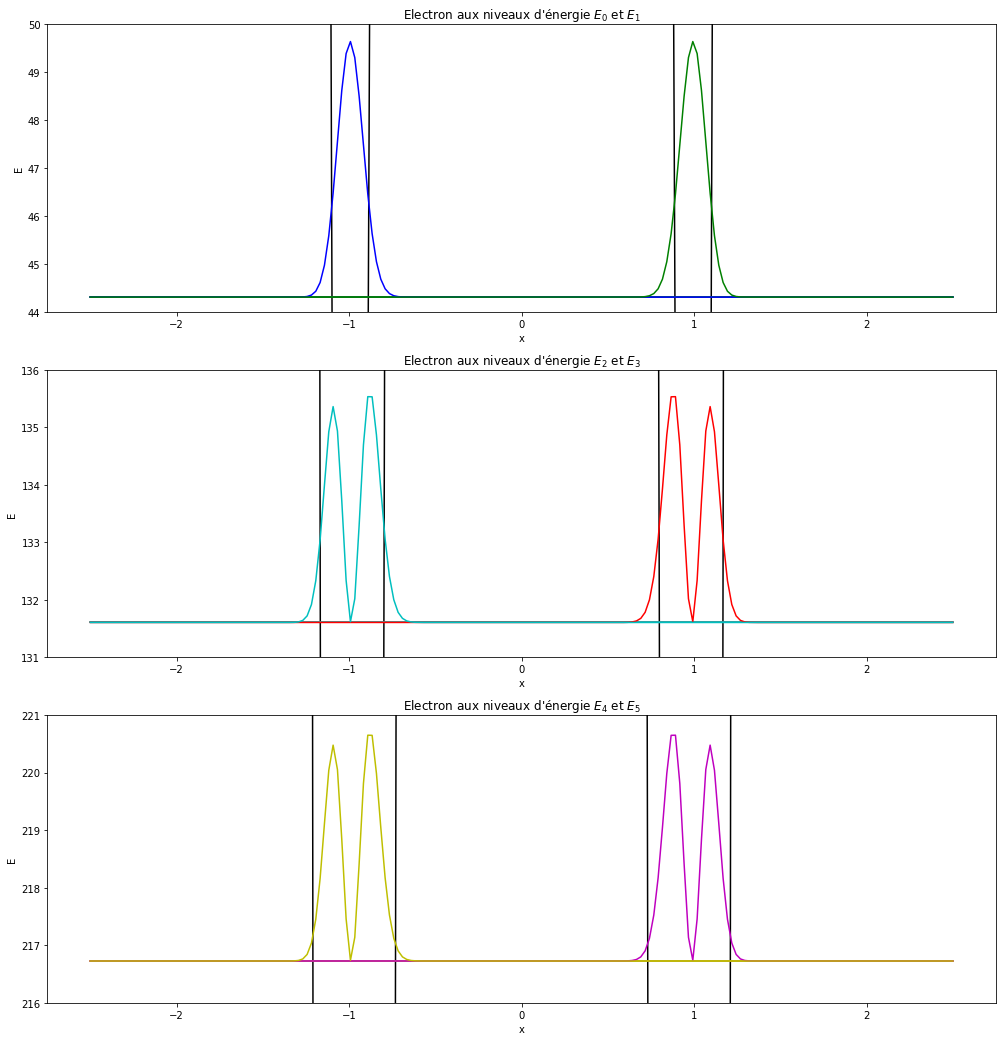

In [317]:
"""Cas V0=1000"""
phidoublepuitshaut=Schrodinger(Double_puits(X, 1000),X)[1]/(d**0.5)
plt.figure(figsize=(17,18))


"""Electron aux niveaux d'énergie E0 et E1"""

plt.subplot(3,1,1)
plt.plot(X ,Double_puits(X, 1000), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][0]*np.ones(n), color='b')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][1]*np.ones(n), color='g')
plt.plot(X, (phidoublepuitshaut[:,0])**2 + Schrodinger(Double_puits(X, 1000),X)[0][0], color='b')
plt.plot(X, (phidoublepuitshaut[:,1])**2 + Schrodinger(Double_puits(X, 1000),X)[0][1], color='g')
plt.title("Electron aux niveaux d'énergie $E_{0}$ et $E_{1}$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(44,50)


"""Electron aux niveaux d'énergie E2 et E3"""

plt.subplot(3,1,2) 
plt.plot(X ,Double_puits(X, 1000), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][2]*np.ones(n), color='r')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][3]*np.ones(n), color='c')
plt.plot(X, (phidoublepuitshaut[:,2])**2 + Schrodinger(Double_puits(X, 1000),X)[0][2], color='r')
plt.plot(X, (phidoublepuitshaut[:,3])**2 + Schrodinger(Double_puits(X, 1000),X)[0][3], color='c')
plt.title("Electron aux niveaux d'énergie $E_{2}$ et $E_{3}$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(131,136)


"""Electron aux niveaux d'énergie E4 et E5"""

plt.subplot(3,1,3) 
plt.plot(X ,Double_puits(X, 1000), color='k')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][4]*np.ones(n), color='m')
plt.plot(X, Schrodinger(Double_puits(X, 1000),X)[0][5]*np.ones(n), color='y')
plt.plot(X, (phidoublepuitshaut[:,2])**2 + Schrodinger(Double_puits(X, 1000),X)[0][4], color='m')
plt.plot(X, (phidoublepuitshaut[:,3])**2 + Schrodinger(Double_puits(X, 1000),X)[0][5], color='y')
plt.title("Electron aux niveaux d'énergie $E_{4}$ et $E_{5}$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(216,221)

plt.show()


Lorsque $V_{0}=1000$, la barrière est trop élevée pour que l'électron, dans un niveau d'énergie fixé, puisse avoir une probabilité de présence dans les 2 puits à la fois.  

## 19

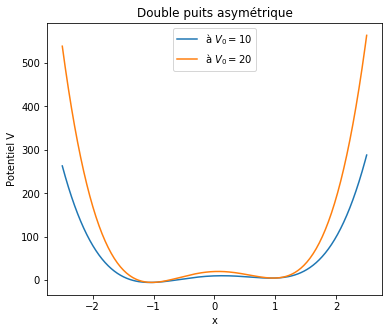

In [318]:
"""F=5"""
def Double_puits_asym(X,V0):
    return V0*(X**2-1)**2+5*X


plt.figure(figsize=(6,5))
plt.plot(X,Double_puits_asym(X,10), label="à $V_{0}=10$")
plt.plot(X,Double_puits_asym(X,20), label="à $V_{0}=20$")
plt.title("Double puits asymétrique")
plt.xlabel('x')
plt.ylabel('Potentiel V')
plt.legend()

plt.show()

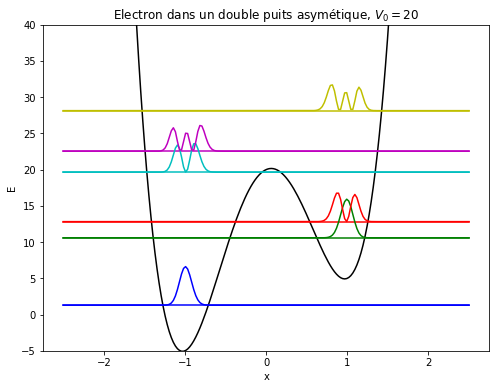

In [319]:
"""Cas V0=20"""

phidoublepuitsasym=Schrodinger(Double_puits_asym(X, 20),X)[1]/(d**0.5)

plt.figure(figsize=(8,6)) 

plt.plot(X ,Double_puits_asym(X, 20), color='k')
plt.plot(X, Schrodinger(Double_puits_asym(X, 20),X)[0][0]*np.ones(n), color='b')
plt.plot(X, Schrodinger(Double_puits_asym(X, 20),X)[0][1]*np.ones(n), color='g')
plt.plot(X, Schrodinger(Double_puits_asym(X, 20),X)[0][2]*np.ones(n), color='r')
plt.plot(X, Schrodinger(Double_puits_asym(X, 20),X)[0][3]*np.ones(n), color='c')
plt.plot(X, Schrodinger(Double_puits_asym(X, 20),X)[0][4]*np.ones(n), color='m')
plt.plot(X, Schrodinger(Double_puits_asym(X, 20),X)[0][5]*np.ones(n), color='y')

plt.plot(X, (phidoublepuitshaut[:,0])**2 + Schrodinger(Double_puits_asym(X, 20),X)[0][0], color='b')
plt.plot(X, (phidoublepuitshaut[:,1])**2 + Schrodinger(Double_puits_asym(X, 20),X)[0][1], color='g')
plt.plot(X, (phidoublepuitshaut[:,2])**2 + Schrodinger(Double_puits_asym(X, 20),X)[0][2], color='r')
plt.plot(X, (phidoublepuitshaut[:,3])**2 + Schrodinger(Double_puits_asym(X, 20),X)[0][3], color='c')
plt.plot(X, (phidoublepuitshaut[:,4])**2 + Schrodinger(Double_puits_asym(X, 20),X)[0][4], color='m')
plt.plot(X, (phidoublepuitshaut[:,5])**2 + Schrodinger(Double_puits_asym(X, 20),X)[0][5], color='y')
plt.title("Electron dans un double puits asymétique, $V_{0}=20$")
plt.xlabel('x')
plt.ylabel('E')
plt.ylim(-5,40)

plt.show()


## Electron dans un cristal

## 20

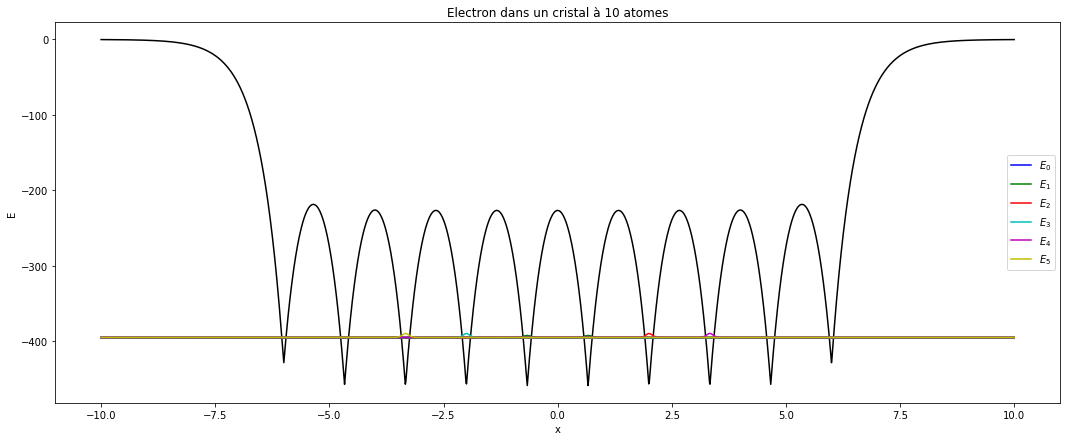

In [320]:
n=2000
L=20
X=np.linspace(-L/2,L/2,n)
d=X[1]-X[0]

A=10 #atomes
Xa=np.linspace(-6,6,A)

def Potentiel_cristal(X, V0):
    V=0
    for k in Xa:
        V+=-V0*np.exp(-np.absolute(X-k)/0.5)
    return V

"""Tracé du graphique"""

phicristal=Schrodinger(Potentiel_cristal(X, 400),X)[1]/(d**0.5)

plt.figure(figsize=(18,7)) 

plt.plot(X ,Potentiel_cristal(X, 400), color='k')
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][0]*np.ones(n), color='b', label="$E_{0}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][1]*np.ones(n), color='g', label="$E_{1}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][2]*np.ones(n), color='r', label="$E_{2}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][3]*np.ones(n), color='c', label="$E_{3}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][4]*np.ones(n), color='m', label="$E_{4}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][5]*np.ones(n), color='y', label="$E_{5}$")


plt.plot(X, (phicristal[:,0])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][0], color='b')
plt.plot(X, (phicristal[:,1])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][1], color='g')
plt.plot(X, (phicristal[:,2])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][2], color='r')
plt.plot(X, (phicristal[:,3])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][3], color='c')
plt.plot(X, (phicristal[:,4])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][4], color='m')
plt.plot(X, (phicristal[:,5])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][5], color='y')
plt.title("Electron dans un cristal à 10 atomes")
plt.xlabel('x')
plt.ylabel('E')
plt.legend()

plt.show()



Si on réalise un zoom sur les niveaux d'énergie de la figure :

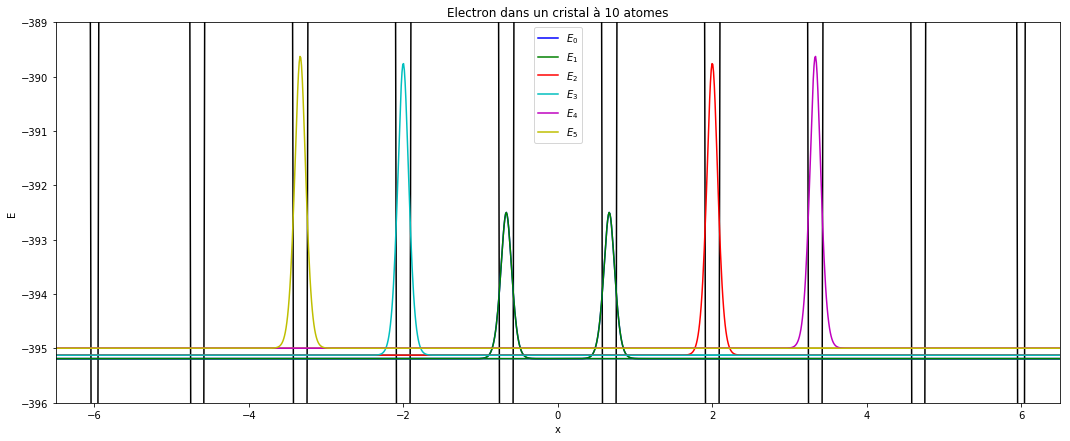

In [321]:
"""Zoom sur le graphique"""

phicristal=Schrodinger(Potentiel_cristal(X, 400),X)[1]/(d**0.5)

plt.figure(figsize=(18,7)) 

plt.plot(X ,Potentiel_cristal(X, 400), color='k')
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][0]*np.ones(n), color='b', label="$E_{0}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][1]*np.ones(n), color='g', label="$E_{1}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][2]*np.ones(n), color='r', label="$E_{2}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][3]*np.ones(n), color='c', label="$E_{3}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][4]*np.ones(n), color='m', label="$E_{4}$")
plt.plot(X, Schrodinger(Potentiel_cristal(X, 400),X)[0][5]*np.ones(n), color='y', label="$E_{5}$")


plt.plot(X, (phicristal[:,0])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][0], color='b')
plt.plot(X, (phicristal[:,1])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][1], color='g')
plt.plot(X, (phicristal[:,2])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][2], color='r')
plt.plot(X, (phicristal[:,3])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][3], color='c')
plt.plot(X, (phicristal[:,4])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][4], color='m')
plt.plot(X, (phicristal[:,5])**2 + Schrodinger(Potentiel_cristal(X, 400),X)[0][5], color='y')
plt.title("Electron dans un cristal à 10 atomes")
plt.xlabel('x')
plt.ylabel('E')
plt.xlim(-6.5,6.5)
plt.ylim(-396,-389)
plt.legend()

plt.show()


Quel que soit l'énergie de l'électron, il reste confiné autour de son atome.

Comme dans le cas du double puits à potentiel $V_{0}$ élevé ($V_{0}=1000$), on observe que les niveaux d'énergies se confondent 2 à 2. Les fonctions $\phi_{0}$ et $\phi_{1}$ sont superposées, tandis que par symétrie de la figure les fonctions $\phi_{2}$ et $\phi_{3}$ d'une part, et $\phi_{4}$ et $\phi_{5}$ d'autre part, sont symétriques. 

## Conclusion

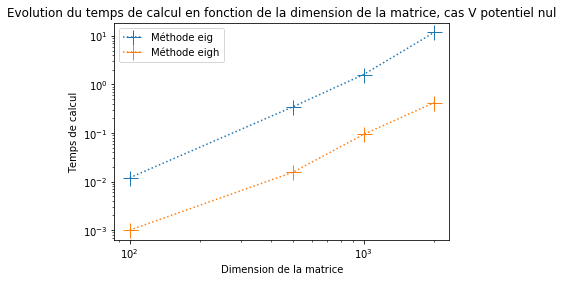

In [322]:
""""Avec le potentiel V nul"""

N=np.array([100,500,1000, 2000]) #liste de dimensions de la matrice H
T_eig=np.zeros(len(N)) # vecteur des temps de calcul par la fonction eig
T_eigh=np.zeros(len(N)) # vecteur des temps de calcul par la fonction eigh
for k in range (len(N)): 

    V=np.zeros(N[k])

    Ma=np.zeros((N[k],N[k])) # Matrice H prise en entrée par eig
    
    Hd=np.zeros(N[k]) # vecteurs diagonal et sous-diagonale pris en entrée par eigh
    Hsousd=np.zeros(N[k]-1)
    
    for j in range(N[k]):
        Hd[j]=1/(d**2) + V[j]
        Ma[j,j]=Hd[j]
    
    for j in range(N[k]-1):
        Hsousd[j]=-1/(2*(d**2))
        Ma[j,j+1]=Ma[j+1,j]=Hsousd[j]
        
    debut_calcul=time()
    eig(Ma, left=True)
    fin_calcul=time() 
    T_eig[k]=fin_calcul-debut_calcul
    
    debut_calcul=time()
    eigh_tridiagonal(Hd,Hsousd)
    fin_calcul=time() 
    T_eigh[k]=fin_calcul-debut_calcul


plt.loglog(N,T_eig,marker='+',markersize=15, linestyle=':', label="Méthode eig") # échelle loglog
plt.loglog(N,T_eigh,marker='+',markersize=15, linestyle=':', label="Méthode eigh")
plt.title("Evolution du temps de calcul en fonction de la dimension de la matrice, cas V potentiel nul")
plt.xlabel('Dimension de la matrice')
plt.ylabel('Temps de calcul')
plt.legend()

plt.show()

Le temps de calcul augmente exponentiellement avec la dimension de la matrice (tracé en échelle loglog).

Résoudre un problème en 3D avec une résolution n revient à travailler avec une matrice carrée de taille 3n.
Résoudre le comportement de 100 électrons revient à réaliser 100 fois le calcul pour un électron. 
Donc si n=1000, on doit diagonaliser une matrice 3000 par 3000 pour chaque électron.

D'après le graphique ci-dessous, le calcul d'un électron dure 1.2s avec eigh (et 36.4s avec eig), soit 120s=2mn de temps d'attente avec eigh pour résoudre un problème d'une centaine d'électrons (et 1h d'attente avec eig).
Même en utilisant eigh, cela prend déjà un temps conséquent pour une molécule simple et un modèle de potentiel du cristal simplifié.

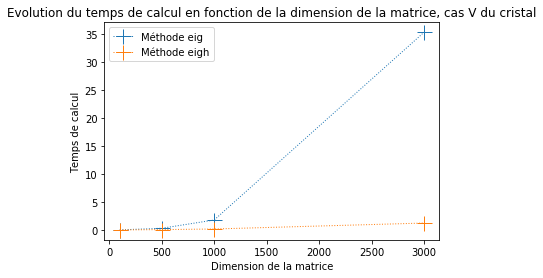

In [323]:
"""Avec le potentiel V du cristal"""

N=np.array([100,500,1000,3000])
T_eig=np.zeros(len(N))
T_eigh=np.zeros(len(N))
for k in range (len(N)):
    Xtest=np.linspace(-10,10,N[k])
    d=Xtest[1]-Xtest[0]
    
    V=Potentiel_cristal(Xtest,400)

    Ma=np.zeros((N[k],N[k]))
    
    Hd=np.zeros(N[k])
    Hsousd=np.zeros(N[k]-1)
    
    for j in range(N[k]):
        Hd[j]=1/(d**2) + V[j]
        Ma[j,j]=Hd[j]
    
    for j in range(N[k]-1):
        Hsousd[j]=-1/(2*(d**2))
        Ma[j,j+1]=Ma[j+1,j]=Hsousd[j]
        
    debut_calcul=time()
    eig(Ma, left=True)
    fin_calcul=time() 
    T_eig[k]=fin_calcul-debut_calcul
    
    debut_calcul=time()
    eigh_tridiagonal(Hd,Hsousd)
    fin_calcul=time() 
    T_eigh[k]=fin_calcul-debut_calcul


plt.plot(N,T_eig,marker='+',markersize=15, linestyle=':',linewidth=1, label="Méthode eig") # échelle loglog
plt.plot(N,T_eigh,marker='+',markersize=15, linestyle=':',linewidth=1, label="Méthode eigh")
plt.title("Evolution du temps de calcul en fonction de la dimension de la matrice, cas V du cristal")
plt.xlabel('Dimension de la matrice')
plt.ylabel('Temps de calcul')
plt.legend()
plt.show()